# Interpolation
Interpolation is a mathematical technique used to estimate values between two known values. In the context of shapes, interpolation allows us to smoothly transform one shape into another by gradually blending their corresponding points. This process is widely used in computer graphics, animation, and data visualization to create smooth transitions and morphing effects.

## Morphing Example: Circle to Square

This example demonstrates how to morph (interpolate) between a circle and a square shape. The process involves gradually transforming the points of a circle into the corresponding points of a square, creating a smooth animation between the two shapes.

Below, you'll find code and visualizations illustrating this morphing process.


In [113]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Output, VBox
from IPython.display import display

# Number of points for the shapes
n_points = 100

# Parameter t for the parametric equations.
# Start at -pi/4 (towards the lower right corner of the square) and go counter-clockwise.
t = np.linspace(-np.pi / 4, 7 * np.pi / 4, n_points, endpoint=False)
np.random.shuffle(t)
# Circle coordinates
circle_x = np.cos(t)
circle_y = np.sin(t)

# Square coordinates, each side traversed counter-clockwise like the circle
points_per_side = n_points // 4
s = np.linspace(-1, 1, points_per_side, endpoint=False)
one = np.ones(points_per_side)
right = np.column_stack((one, s))
top = np.column_stack((-s, one))
left = np.column_stack((-one, -s))
bottom = np.column_stack((s, -one))

#Combine all sides to form the full square
square_points = np.vstack((right, top, left, bottom)) # Change the order of stacking and see the effect.

# Extract x and y coordinates for the square
square_x = square_points[:, 0]
square_y = square_points[:, 1]

morph_out = Output()

def show_figure(fig, out):
    """Put the figure in the output widget 'out', replacing the previous one."""
    plt.close(fig)  # the widget shows the figure, so the notebook should not show it too
    data, metadata = get_ipython().display_formatter.format(fig)
    out.outputs = ({'output_type': 'display_data', 'data': data, 'metadata': metadata},)

def morph_shape(alpha):
    x = (1 - alpha) * circle_x + alpha * square_x
    y = (1 - alpha) * circle_y + alpha * square_y
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x, y, 'o', label=f'alpha={alpha:.2f}')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title('Morphing: Circle to Square')
    ax.legend()
    show_figure(fig, morph_out)

slider = FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description='alpha')
slider.observe(lambda change: morph_shape(change['new']), names='value')
morph_shape(slider.value)
display(VBox([slider, morph_out]))

**Task:** Change the order of the stacking of the sides of the square and see the effect. 

Morphing images can be done in the same manner. 

In [103]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# URLs of the portrait images
url_dog = "https://unsplash.com/photos/x5oPmHmY3kQ/download?ixid=M3wxMjA3fDB8MXxzZWFyY2h8Mnx8ZG9nJTIwcG9ydHJhaXR8ZW58MHx8fHwxNzU5MDg1MzAxfDA&force=true&w=640"
url_cat = "https://images.pexels.com/photos/34065256/pexels-photo-34065256.jpeg" 
url_face =  "https://images.unsplash.com/photo-1507003211169-0a1dd7228f2d"
url_building= "https://images.pexels.com/photos/10040106/pexels-photo-10040106.jpeg" 

url1=url_face
url2=url_cat
# Function to download and return an image
def download_image(url):
    response = requests.get(url)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return image

# Download both images
img1 = download_image(url1)
img2 = download_image(url2)

# Shrink the first image so the blending is fast
img1.thumbnail((600, 600))

# Resize second image to match the first
img2 = img2.resize(img1.size)

# Convert images to numpy arrays
arr1 = np.array(img1, dtype=np.float32)
arr2 = np.array(img2, dtype=np.float32)
# Function to display morphed image based on interpolation factor
image_out = widgets.Output()

def show_morphed_image(alpha):
    blended = (1 - alpha) * arr1 + alpha * arr2
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.uint8(blended))
    ax.axis('off')
    ax.set_title(f"Interpolation α = {alpha:.2f}")
    show_figure(fig, image_out)

# Create interactive slider
slider = widgets.FloatSlider(value=0., min=0.0, max=1.0, step=0.05, description='α:', continuous_update=False)
slider.observe(lambda change: show_morphed_image(change['new']), names='value')
show_morphed_image(slider.value)
display(widgets.VBox([slider, image_out]))


### Why is morphing interpolation?

Linear interpolation between two known values $A$ and $B$ is

$$
P(\alpha) = (1-\alpha)\,A + \alpha\,B, \qquad 0 \le \alpha \le 1 .
$$

It reproduces the data, $P(0) = A$ and $P(1) = B$, and fills in the values in between.

The morphing examples use exactly this formula. The only difference is that $A$ and $B$ are not single numbers: for the shapes they are the coordinates of 100 points, and for the images they are the colour values of every pixel. The formula is applied to each point (or pixel) separately, with the same $\alpha$ for all of them.

This is also the simplest case of the Lagrange interpolation we meet below. Take two nodes, $\alpha_0 = 0$ and $\alpha_1 = 1$, with data $A$ and $B$. The Lagrange basis polynomials are

$$
\ell_0(\alpha) = \frac{\alpha - 1}{0 - 1} = 1 - \alpha, \qquad
\ell_1(\alpha) = \frac{\alpha - 0}{1 - 0} = \alpha ,
$$

so $P(\alpha) = A\,\ell_0(\alpha) + B\,\ell_1(\alpha)$ is the interpolating polynomial of degree 1 through the two "data points" $(0, A)$ and $(1, B)$.

Note that the formula only blends *pairs*: point number $i$ on the circle is blended with point number $i$ on the square. Which points are paired is our choice, not part of the interpolation, and that is why the order of the square's sides changes the morph so much.


## Background theory
**Weierstrass Approximation Theorem:**  
Every continuous function defined on a closed interval $[a, b]$ can be uniformly approximated as closely as desired by a polynomial function.

**Horner's Method:**  
Horner's method is an efficient algorithm to evaluate polynomials at a given point.  
For a polynomial $ P(x) = a_n x^n + \dots + a_1 x + a_0 $, Horner's form rewrites it as 

$$
P(x) = (\dots((a_n x + a_{n-1}) x + a_{n-2}) \dots x + a_0)
$$  
which reduces the number of multiplications required.


In [118]:
def horner(a, x):
    """Evaluate the polynomial using Horner's rule:
    p(x) = a(0) + a(1)x + ... + a(n-1)x^(n-1)
    """
    n = len(a)
    p = a[-1]
    for k in range(2, n + 1):
        p = p * x + a[-k]
    return p

def direct(a, x):
    """Evaluate the polynomial term by term:
    p(x) = a(0) + a(1)x + ... + a(n-1)x^(n-1)
    """
    p = 0
    for k in range(len(a)):
        p = p + a[k] * x**k
    return p

# Small example: −x**2 + 2x + 4 at x = 3
a = [4, 2, -1]
x = 3
n = len(a)
print(f"Horner's method evaluation: {horner(a, x)}")
print(f"Direct evaluation: {direct(a, x)}")
print(f"Horner uses {n - 1} multiplications and {n - 1} additions")
print(f"Direct uses {n*(n-1)//2} multiplications and {n-1} additions")  

Horner's method evaluation: 1
Direct evaluation: 1
Horner uses 2 multiplications and 2 additions
Direct uses 3 multiplications and 2 additions


**Task: Is Horner's method also faster?**

Horner's method uses $n$ multiplications to evaluate a polynomial of degree $n$. If we instead compute each term $a_k x^k$ separately, building $x^k$ by multiplying $x$ with itself $k$ times, we need $1 + 2 + \dots + n = \frac{n(n+1)}{2}$ multiplications.

1. Write a function `naive(a, x)` that evaluates the polynomial term by term, where each power $x^k$ is computed with a loop of repeated multiplications (do not use `x**k`). Check that it gives the same value as `horner(a, x)` for the small example above.
2. Before you measure anything: if the degree is doubled, how much longer do you expect `horner` to take? And `naive`?
3. For the degrees $n = 10, 20, 50, 100, 200, 400, 800$, make a polynomial with random coefficients and measure the time of one evaluation with both functions. Use $x = 0.9$.
4. Plot the two times against $n$ with `plt.loglog`. What are the slopes of the two lines, and how do they relate to the number of multiplications?
5. Repeat the measurement with the function `direct(a, x)`, which uses `x**k`. Why is it much closer to Horner's method than `naive` is?

*Hints:*
- `rng = np.random.default_rng(0)` and `a = rng.standard_normal(n + 1).tolist()` give random coefficients.
- `min(timeit.repeat(lambda: horner(a, 0.9), number=100, repeat=5)) / 100` gives a stable time for one evaluation. Use a smaller `number` for `naive` at high degree.
- Use a decimal number close to 1 for $x$. A large $x$ overflows for high degrees, and an integer $x$ makes Python use very large integers, which disturbs the timing.


## Lagrange Interpolation Polynomials

**Lagrange interpolation** is a classical method for constructing a polynomial that passes exactly through a given set of data points. Given $n+1$ distinct data points $(x_0, y_0), (x_1, y_1), \ldots, (x_n, y_n)$, the Lagrange interpolating polynomial $P(x)$ of degree at most $n$ is defined as:

$$
P(x) = \sum_{j=0}^{n} y_j \ell_j(x)
$$

where each $\ell_j(x)$ is the **Lagrange basis polynomial**:

$$
\ell_j(x) = \prod_{\substack{0 \leq m \leq n \\ m \neq j}} \frac{x - x_m}{x_j - x_m}
$$

### Properties

- $\ell_j(x_k) = 1$ if $j = k$, and $0$ otherwise.
- Each $\ell_j(x)$ is a polynomial of degree $n$.
- The interpolating polynomial $P(x)$ passes through all the given points: $P(x_j) = y_j$ for all $j$.
- The method is **exact** for polynomials of degree up to $n$.

Each $\ell_j(x)$ "picks out" the value $y_j$ at $x_j$ and is zero at all other nodes. The shape of the $\ell_j(x)$ polynomials shows how each node influences the interpolation at different $x$ values.

### Advantages

- Simple, explicit formula.
- No need to solve a system of equations.

### Disadvantages

- Computationally expensive for large $n$.
- Susceptible to **Runge’s phenomenon** (oscillations) for high-degree polynomials on equidistant nodes. This is a property of the interpolating polynomial itself, not of the Lagrange form.

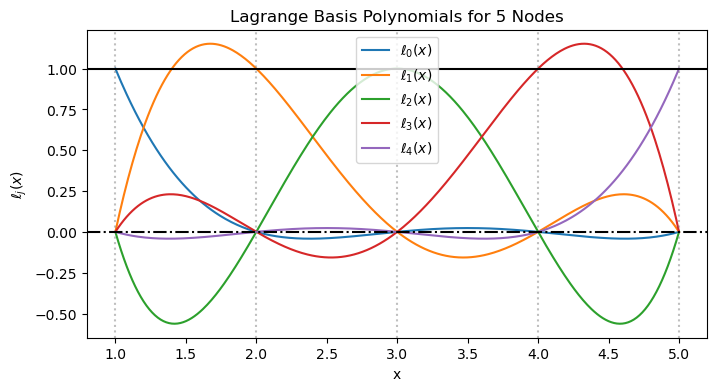

In [116]:
# Plot the Lagrange basis polynomials l_j(x) for 5 equidistant nodes
def lagrange_basis(x_nodes, j, x):
    """Compute the j-th Lagrange basis polynomial at x."""
    basis = 1
    n = len(x_nodes)
    for m in range(n):
        if m != j:
            basis *= (x - x_nodes[m]) / (x_nodes[j] - x_nodes[m])
    return basis

x_nodes=[1, 2., 3, 4, 5]
x_values = np.linspace(1, 5, 400)
plt.figure(figsize=(8, 4))
for j in range(len(x_nodes)):
    l_j = [lagrange_basis(x_nodes, j, xi) for xi in x_values]
    plt.plot(x_values, l_j, label=rf'$\ell_{j}(x)$')
for node in x_nodes:
    plt.axvline(node, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
plt.axhline(1, color='black', linewidth=1.5)
plt.axhline(0, color='black', linewidth=1.5,linestyle='-.')
plt.xlabel('x')
plt.ylabel(r'$\ell_j(x)$')
plt.title('Lagrange Basis Polynomials for 5 Nodes')
plt.legend()
plt.grid(False)
plt.show()

**Tasks:** 

- The figure only shows the $x$-interval of the nodes. What happens outside of that interval?
- The figure has equidistant nodes. Can you define nodes that are not equidistant?

### Example 2 p 194
Consider the function $f(x) = \sqrt{x}$ at the points $x = 1, 2, 3$.  
We want to construct the interpolating polynomial that passes through the points:

| $x$ | $f(x)$   |
|-----|----------|
| 1   | 1.0000   |
| 2   | 1.4142   |
| 3   | 1.7321   |

To construct the interpolating polynomial, we use the Lagrange interpolation formula:

$$
P(x) = \sum_{j=0}^{2} f(x_j) \ell_j(x)
$$

where the Lagrange basis polynomials are:

- $\ell_0(x) = \dfrac{(x-2)(x-3)}{(1-2)(1-3)}=\dfrac{1}{2}(x-2)(x-3)$

- $\ell_1(x) = \dfrac{(x-1)(x-3)}{(2-1)(2-3)}=-(x-1)(x-3)$

- $\ell_2(x) = \dfrac{(x-1)(x-2)}{(3-1)(3-2)}=\dfrac{1}{2}(x-1)(x-2)$

Plugging in the function values:

- $f(1) = 1.0000$
- $f(2) = 1.4142$
- $f(3) = 1.7321$

So,

$$
\begin{align*}
P(x) =\ & 1.0000 \cdot \dfrac{1}{2} (x-2)(x-3)\\
&- 1.4142 \cdot (x-1)(x-3) \\
&+ 1.7321 \cdot \dfrac{1}{2}(x-1)(x-2)
\end{align*}
$$

Expanding and simplifying gives the explicit quadratic polynomial that interpolates the points.

In [83]:
def lagrange_interpolating_polynomial(x_points, y_points):
    """
    Returns a function representing the Lagrange interpolating polynomial
    for the given data points (x_points, y_points).
    """
    def P(x):
        total = 0
        n = len(x_points)
        for j in range(n):
            # Compute the j-th Lagrange basis polynomial
            lj = 1
            for m in range(n):
                if m != j:
                    lj *= (x - x_points[m]) / (x_points[j] - x_points[m])
            total += y_points[j] * lj
        return total
    return P

In [108]:
p=lagrange_interpolating_polynomial([1, 2, 3], [np.sqrt(1), np.sqrt(2), np.sqrt(3)])
print(f"Type of p: {type(p)}")
print(f"Value of p at x=2.5: {p(2.5)}")

Type of p: <class 'function'>
Value of p at x=2.5: 1.5851792246181504


In [110]:
x = 1.2 # Try the nodes 1, 2, 3 and see that p(x) = sqrt(x)
p(x) - np.sqrt(x)

-0.004892297161527948

To add another point x=1.2, f(1.2)=$\sqrt{1.2}$ we need to make a new function


In [111]:
p1=lagrange_interpolating_polynomial([1, 1.2, 2, 3], [np.sqrt(1), np.sqrt(1.2), np.sqrt(2), np.sqrt(3)])
p1(x) - np.sqrt(x)

0.0

**Tasks** Look at the error outside of the data points, for instance x=4. 

Let's plot the results. 

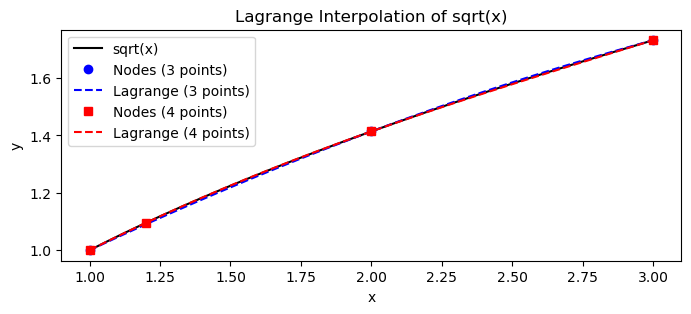

In [87]:
x = np.linspace(1, 3, 400)
plt.figure(figsize=(8, 3))
# Plot the true function
plt.plot(x, np.sqrt(x), label='sqrt(x)', color='black')
# Plot the nodes for 3-point interpolation
x_nodes_3 = [1, 2, 3]
y_nodes_3 = np.sqrt(x_nodes_3)
p3=lagrange_interpolating_polynomial(x_nodes_3, y_nodes_3)
plt.plot(x_nodes_3, y_nodes_3, 'o', label='Nodes (3 points)', color='blue')
# Plot the 3-point interpolation
plt.plot(x, p3(x), label='Lagrange (3 points)', color='blue', linestyle='--')
# Plot the nodes for 4-point interpolation
x_nodes_4 = [1, 1.2, 2, 3]
y_nodes_4 = np.sqrt(x_nodes_4)
p4 = lagrange_interpolating_polynomial(x_nodes_4, y_nodes_4)
plt.plot(x_nodes_4, y_nodes_4, 's', label='Nodes (4 points)', color='red')
# Plot the 4-point interpolation
plt.plot(x, p4(x), label='Lagrange (4 points)', color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Interpolation of sqrt(x)')
plt.legend()
plt.show()

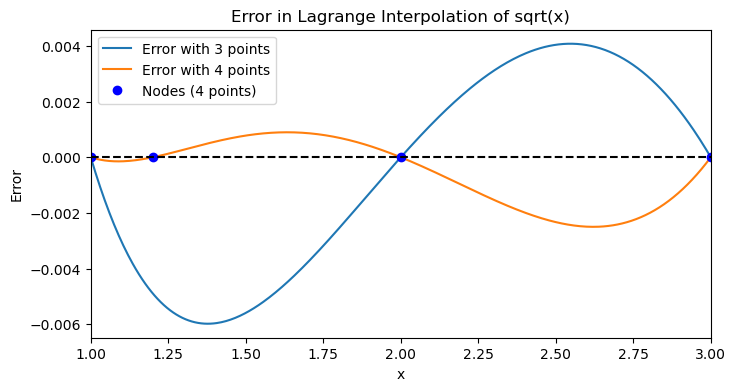

In [88]:
x = np.linspace(1, 3, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, p3(x) - np.sqrt(x), label='Error with 3 points')
plt.plot(x, p4(x) - np.sqrt(x), label='Error with 4 points')
plt.plot(x_nodes_4, [0]*len(x_nodes_4), 'o', label='Nodes (4 points)', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Error in Lagrange Interpolation of sqrt(x)')
plt.xlim(1, 3)
plt.legend();


**Tasks** Extend the x interval beyond the interval $x\in [1,3]$. 

### Reproducing figure 6.1
Remember that 
$$
 f(x)-p(x)=\frac{L(x)}{(N+1)!}f^{(N+1)}(\xi)
$$ with
$$
 L(x)= \prod_{k=0}^{N} (x-x_k)
$$

In figure 6.1 the function $L(x)=(x-1)(x-1.5)(x-2)(x-2.5)(x-3)$. 

The nodes for this interpolation are $x = 1,\, 1.5,\, 2,\, 2.5,\, 3$. 

These are the points where the polynomial $L(x)$ is zero, and they define the interval of interest for the interpolation. Inside $[1, 3]$ the polynomial $L(x)$ stays small, but it is larger in the two end subintervals than in the middle. With more equidistant nodes this difference grows, which is the mechanism behind Runge's phenomenon: the interpolation error is largest near the endpoints. Outside the interval, $|L(x)|$ grows rapidly, which is why extrapolation with the interpolating polynomial is unreliable.


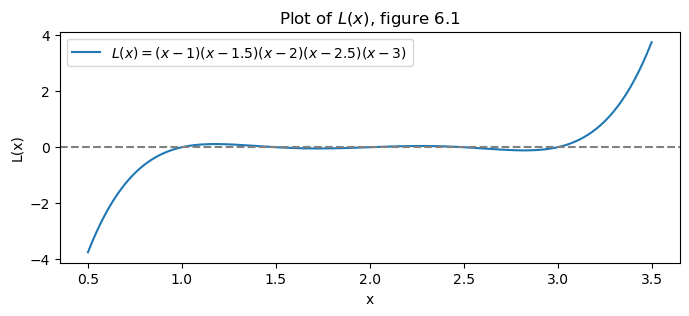

In [89]:
L = lambda x: (x - 1) * (x - 1.5) * (x - 2) * (x - 2.5) * (x - 3)
x_L = np.linspace(0.5, 3.5, 400) # Try (1,3) and (0,4)
plt.figure(figsize=(8, 3))
plt.plot(x_L, L(x_L), label=r'$L(x)=(x-1)(x-1.5)(x-2)(x-2.5)(x-3)$')
plt.xlabel('x')
plt.ylabel('L(x)')
plt.title('Plot of $L(x)$, figure 6.1')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.show()

**Task:** Zoom in on $x\in [1,3]$, then add new nodes at your own choice in the interval. You can use the code below. 

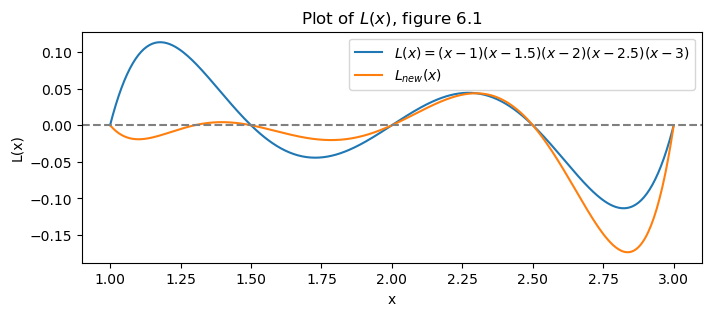

In [ ]:
L = lambda x: (x - 1) * (x - 1.5) * (x - 2) * (x - 2.5) * (x - 3)
L_new = lambda x: (x - 1) *  (x - 1.5) * (x - 2) * (x - 2.5) * (x - 3)
x_L = np.linspace(1, 3, 400) # Try (1,3) and (0,4)
plt.figure(figsize=(8, 3))
plt.plot(x_L, L(x_L), label=r'$L(x)=(x-1)(x-1.5)(x-2)(x-2.5)(x-3)$')
plt.plot(x_L, L_new(x_L), label=r'$L_{new}(x)$')
plt.xlabel('x')
plt.ylabel('L(x)')
plt.title('Plot of $L(x)$, figure 6.1')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.show()

### Example: Lagrange Interpolation for Runge’s Function

Runge’s function is defined as:

$$
f(x) = \frac{1}{1 + x^2}
$$

Let's interpolate this function using Lagrange interpolation with equidistant nodes and compare the interpolation to the true function.


In [112]:
from ipywidgets import IntSlider

# Define Runge's function
def runge(x):
    return 1 / (1 + x**2)

# Choose equidistant nodes
def plot_runge_interpolation(num_nodes):
    x_nodes = np.linspace(-5, 5, num_nodes)
    y_nodes = runge(x_nodes)
    p_runge = lagrange_interpolating_polynomial(x_nodes, y_nodes)
    x = np.linspace(-5, 5, 400)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, runge(x), label="Runge's Function", color='black')
    ax.plot(x, p_runge(x), label=f'Lagrange Interpolation ({num_nodes} points)', linestyle='--', color='red')
    ax.scatter(x_nodes, y_nodes, color='blue', zorder=5, label='Interpolation Nodes')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title("Runge's Function and Its Lagrange Interpolation")
    ax.legend()
    show_figure(fig, runge_out)

runge_out = Output()
runge_slider = IntSlider(value=2, min=2, max=20, step=1, description='Nodes')
runge_slider.observe(lambda change: plot_runge_interpolation(change['new']), names='value')
plot_runge_interpolation(runge_slider.value)
display(VBox([runge_slider, runge_out]))


## Difference Representation


Difference representation such as Newton's divided differences
is a good approach to interpolation for several reasons:

- **Efficiency for Adding Points:** When a new data point is added, you do not need to recompute the entire polynomial from scratch. You can update the divided difference table incrementally.
- **Computational Simplicity:** The polynomial can be evaluated efficiently using nested multiplication (Horner's method).
- **Flexibility:** The method works well for both evenly and unevenly spaced data points.

In summary, difference representation makes polynomial interpolation more efficient and flexible, especially when working with many or changing data points.

Functions to calculate the divided difference and subsequent evaluation of the polynomial. 

In [92]:
# Function to compute divided differences
def newton_divided_diff(x, y):
    n = len(x)
    D = np.zeros((n, n))
    for j in range(n):
        D[j, 0] = y[j]
    for j in range(1, n):
        for i in range(n - j):
            D[i, j] = (D[i + 1, j - 1] - D[i, j - 1]) / (x[i + j] - x[i])
    coef = D[0, :]  # Coefficients are in the first row
    return D

# Function to evaluate Newton's polynomial at x
def newton_poly(coef, x_data, x):
    n = len(coef)
    p = coef[-1]
    for k in range(2, n+1):
        p = coef[-k] + (x - x_data[-k]) * p
    return p



### Example: Newton's Divided Differences

Given the data points:

| $k$ | $x_k$ | $f(x_k)$ |
|-----|-------|----------|
| 0   | 2     | 4        |
| 1   | 3     | 2        |
| 2   | 5     | 1        |

Let's compute the divided difference table and write the Newton interpolating polynomial.


- Zeroth order (function values):
    - $f[x_0] = f(2) = 4$
    - $f[x_1] = f(3) = 2$
    - $f[x_2] = f(5) = 1$

- First order:
    - $f[x_0, x_1] = \dfrac{f[x_1] - f[x_0]}{x_1 - x_0} = \dfrac{2 - 4}{3 - 2} = -2$
    
    - $f[x_1, x_2] = \dfrac{f[x_2] - f[x_1]}{x_2 - x_1} = \dfrac{1 - 2}{5 - 3} = -0.5$

- Second order:
    - $f[x_0, x_1, x_2] = \dfrac{f[x_1, x_2] - f[x_0, x_1]}{x_2 - x_0} = \dfrac{-0.5 - (-2)}{5 - 2} = \dfrac{1.5}{3} = 0.5$



In [93]:
x_nodes = np.array([2,3,5])
y_nodes = np.array([4,2,1])
D = newton_divided_diff(x_nodes, y_nodes)
D

array([[ 4. , -2. ,  0.5],
       [ 2. , -0.5,  0. ],
       [ 1. ,  0. ,  0. ]])

**Task**: What happens if you add a point to the data, say $(x,y)=(7,0)$ or $(x,y)=(2.5,3)$?


### Example 5: Newton’s Divided Difference Interpolation for $\sqrt{0.3}$ and $\sqrt{1.1}$

Given data:

| $x$   | $0.2$   | $0.6$   | $1.2$   | $1.5$   |
|-------|---------|---------|---------|---------|
| $\sqrt{x}$ | $0.4472$ | $0.7746$ | $1.0954$ | $1.2247$ |

We want to estimate $\sqrt{0.3}$ and $\sqrt{1.1}$ using Newton’s divided difference formula.

**Step 1: Prepare the data**


Let  
$x_{\text{data}} = [0.2, 0.6, 1.2, 1.5]$  
$y_{\text{data}} = [0.4472, 0.7746, 1.0954, 1.2247]$


In [94]:
# Given data
x_data = np.array([0.2, 0.6, 1.2, 1.5])
y_data = np.array([0.4472, 0.7746, 1.0954, 1.2247])


**Step 2: Compute the divided difference table and interpolate**


In [95]:
import math
# Compute coefficients
D = newton_divided_diff(x_data, y_data)
coef = D[0, :]  # Coefficients are in the first row
print("Divided Difference Table D:")
print(D)


# Estimate sqrt(0.3) and sqrt(1.1)
x_vals = [0.3, 1.1]
estimates = [newton_poly(coef, x_data, xv) for xv in x_vals]
for i, xv in enumerate(x_vals):
    print(f"Estimated sqrt({xv}): {estimates[i]:.6f}")
    print(f"Actual sqrt({xv}): {math.sqrt(xv):.6f}")
    print(f"Error: {estimates[i] - math.sqrt(xv):.6f}")
    




Divided Difference Table D:
[[ 0.4472      0.8185     -0.28383333  0.12972934]
 [ 0.7746      0.53466667 -0.11518519  0.        ]
 [ 1.0954      0.431       0.          0.        ]
 [ 1.2247      0.          0.          0.        ]]
Estimated sqrt(0.3): 0.541068
Actual sqrt(0.3): 0.547723
Error: -0.006655
Estimated sqrt(1.1): 1.050287
Actual sqrt(1.1): 1.048809
Error: 0.001478


### Sorting the data points
Turner now turns to a way of avoiding polynomials of high degree, to avoid fluctuations between the nodes. The function below is an adjusted version of their code. It sorts the data points by distance to the point we want to evaluate, so that the nearest points are used first. For $x = 1.1$ and the data above, the order becomes $1.2,\ 1.5,\ 0.6,\ 0.2$.

In [96]:
# The function from Turner, p. 204
def ddiff1(xdat, ydat, x, max_degree=None, sort=True):
    """
    Function for computing Newton's divided difference formula using nearest data points in
    'xdat', 'ydat' to elements of 'x' first. Taken from Turner, p. 204.
    Input:
      xdat, ydat : data points for interpolation, dimensions M
      x          : points to evaluate the interpolation at, dimension N
    Output:
      y          : interpolated values at points in x
      D          : divided difference table
    Altered to allow for a maximum degree 'max_degree' of the polynomial
    (default: use all data points).
    """
    N = x.size
    M = xdat.size
    D = np.zeros((M, M))
    y = np.zeros(N)
    # A polynomial of degree d uses d + 1 data points (terms in Newton's formula)
    if max_degree is not None and max_degree + 1 < M:
        n_terms = max_degree + 1
    else:
        n_terms = M
    for k in range(N):
        # Sort contents of input data arrays
        xtst = x[k]
        if sort is False:
            xsort = xdat
            D[:, 0] = ydat
        else:
            ind = np.argsort(np.abs(xtst - xdat))
            xsort = xdat[ind]
            D[:, 0] = ydat[ind]
        # Begin divided differences
        for j in range(M - 1):
            for i in range(M - j - 1):
                D[i, j + 1] = (D[i + 1, j] - D[i, j]) / (xsort[i + j + 1] - xsort[i])
        # End divided differences
        # Compute interpolation
        xdiff = xtst - xsort
        prod = 1  # Holds the product of xdiff
        for i in range(n_terms):
            y[k] = y[k] + prod * D[0, i]
            prod = prod * xdiff[i]
    return y, D

In [128]:
# Compute the divided difference interpolation
x_eval = np.asarray(x_vals)
x_target = x_eval[:2]
print(f"Estimating sqrt({x_target[0]}) using divided differences:")
Y, D = ddiff1(x_data, y_data, x_target, max_degree=2, sort=True)
print("Divided Difference Table D:")
print(D)

print(f"Estimated sqrt({x_target[0]}): {Y[0]:.6f}")
print(f"Actual sqrt({x_target[0]}): {np.sqrt(x_target[0]):.6f}")

Estimating sqrt(0.3) using divided differences:
Divided Difference Table D:
[[ 1.0954      0.431      -0.11518519  0.12972934]
 [ 1.2247      0.50011111 -0.24491453  0.        ]
 [ 0.7746      0.8185      0.          0.        ]
 [ 0.4472      0.          0.          0.        ]]
Estimated sqrt(0.3): 0.537565
Actual sqrt(0.3): 0.547723


### Runge's example (revisited)


In [98]:
from ipywidgets import IntSlider
x_dense = np.linspace(-5, 5, 400)
y_dense = 1 / (1 + x_dense**2)
def plot_newton_interp(num_points,max_degree=4):
    x_points = np.linspace(-5, 5, num_points)
    y_points = 1 / (1 + x_points**2)
    y_interp, D = ddiff1(x_points, y_points, x_dense, max_degree=max_degree, sort=True)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(x_points, y_points, 'o', label='Interpolation nodes')
    ax.plot(x_dense, y_interp, '--', label='Newton interp.')
    ax.plot(x_dense, y_dense, '-', label='y = 1/(1 + x^2)')
    ax.set_title('Function y = 1/(1 + x^2)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    show_figure(fig, newton_out)

newton_out = Output()
points_slider = IntSlider(value=11, min=2, max=20, step=1, description='x_points')
degree_slider = IntSlider(value=20, min=1, max=20, step=1, description='max_degree')

def update_newton_plot(change=None):
    plot_newton_interp(points_slider.value, degree_slider.value)

points_slider.observe(update_newton_plot, names='value')
degree_slider.observe(update_newton_plot, names='value')
update_newton_plot()
display(VBox([points_slider, degree_slider, newton_out]))


**Task:** Can you plot the error?

## Splines

Splines are a powerful family of piecewise polynomial functions used for interpolation and smoothing of data. Unlike high-degree global polynomials, which can oscillate wildly between data points (especially with many equidistant points), splines construct smooth curves by joining low-degree polynomials at specified points called **knots**. The most common type, the **cubic spline**, ensures that the resulting curve is not only continuous but also has continuous first and second derivatives, producing a visually smooth and stable interpolation.

**Key features of splines:**
- **Piecewise polynomial:** The domain is divided into intervals, with a separate polynomial on each interval.
- **Smoothness:** Splines are constructed so that the curve and its derivatives up to a certain order are continuous at the knots.
- **Stability:** Splines avoid the oscillatory behavior of high-degree polynomials, making them ideal for practical interpolation and data fitting.

Splines are widely used in computer graphics, engineering, data science, and numerical analysis for tasks such as curve fitting, animation, and numerical solutions to differential equations.

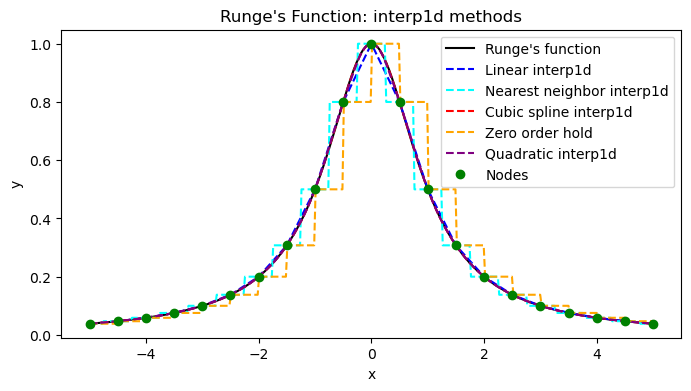

In [99]:
from scipy.interpolate import interp1d

# Define Runge's function
def runge(x):
    return 1 / (1 + x**2)

# Choose interpolation nodes and dense evaluation points
x_nodes = np.linspace(-5, 5, 21)
y_nodes = runge(x_nodes)
x_dense = np.linspace(-5, 5, 400)
y_true = runge(x_dense)

#nearest neighbor interpolation
f_nearest = interp1d(x_nodes, y_nodes, kind='nearest')
y_nearest = f_nearest(x_dense)
#zero order hold
f_zero = interp1d(x_nodes, y_nodes, kind='zero')
y_zero = f_zero(x_dense)

# Linear interpolation
f_linear = interp1d(x_nodes, y_nodes, kind='linear')
y_linear = f_linear(x_dense)

# Quadratic interpolation
f_quad = interp1d(x_nodes, y_nodes, kind='quadratic')
y_quad = f_quad(x_dense)

# Cubic spline interpolation
f_cubic = interp1d(x_nodes, y_nodes, kind='cubic')
y_cubic = f_cubic(x_dense)

plt.figure(figsize=(8, 4))
plt.plot(x_dense, y_true, label="Runge's function", color='black')
plt.plot(x_dense, y_linear, '--', label='Linear interp1d', color='blue')
plt.plot(x_dense, y_nearest, '--', label='Nearest neighbor interp1d', color='cyan')
plt.plot(x_dense, y_cubic, '--', label='Cubic spline interp1d', color='red')
plt.plot(x_dense, y_zero, '--', label='Zero order hold', color='orange')
plt.plot(x_dense, y_quad, '--', label='Quadratic interp1d', color='purple')
plt.plot(x_nodes, y_nodes, 'o', label='Nodes', color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Runge's Function: interp1d methods")
plt.legend()
plt.show()

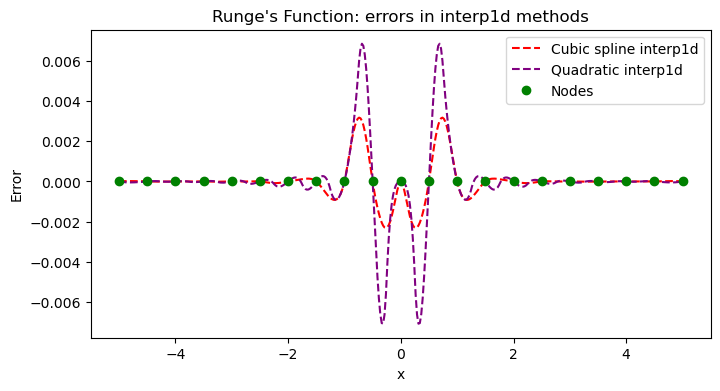

In [100]:
plt.figure(figsize=(8, 4))

#plt.plot(x_dense, y_linear-y_true, '--', label='Linear interp1d', color='blue')
#plt.plot(x_dense, y_nearest-y_true, '--', label='Nearest neighbor interp1d', color='cyan')
plt.plot(x_dense, y_cubic-y_true, '--', label='Cubic spline interp1d', color='red')
#plt.plot(x_dense, y_zero-y_true, '--', label='Zero order hold', color='orange')
plt.plot(x_dense, y_quad-y_true, '--', label='Quadratic interp1d', color='purple')
plt.plot(x_nodes, 0*y_nodes, 'o', label='Nodes', color='green')
plt.xlabel('x')
plt.ylabel('Error')
plt.title("Runge's Function: errors in interp1d methods")
plt.legend()
plt.show()